In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import h5py

In [3]:
def inspect_hdf5(path_h5:str):
    """Recursively print all fields in the hdf5 with their shape and dtype"""
    print(f"Inspecting file {path_h5}")
    def inspect_hdf5_rec(item):
        if isinstance(item, h5py.Dataset):
            print(item.name, item.shape, item.dtype, item.chunks)
        else:
            for child in item.values():
                inspect_hdf5_rec(child)
    with h5py.File(path_h5, "r") as file_h5:
        inspect_hdf5_rec(file_h5)
    print()

# Bam to hdf5

In [4]:
from hapROH.utils.IO import bam2hdf5

In [5]:
prefix_ref_HDF5 = "../Data/reference/1000g_maf5_hdf5/maf5_chr"
path_meta_ref = "../Data/reference/meta_1000g.csv"

In [6]:
sample_name = "SB606"
path_sample_bam = f"../Data/ExampleData/med_jews/bam/{sample_name}.merged.rg.markdup.indrealn_recalibrated.bam"
prefix_sample_HDF5 = f"../Data/ExampleData/med_jews/HDF5/{sample_name}.chr"

In [7]:
for ch in range(1,23):
    bam2hdf5(path_sample_bam, prefix_ref_HDF5+f"{ch}.hdf5", prefix_sample_HDF5+f"{ch}.hdf5", sample_name, chrom=ch, overwrite=False)

File ../Data/ExampleData/med_jews/HDF5/SB606.chr1.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr2.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr3.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr4.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr5.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr6.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr7.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr8.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr9.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med

## Inspect hdf5

In [8]:
chrom = 1
path_sample = prefix_sample_HDF5 + f"{chrom}.hdf5"
path_ref = prefix_ref_HDF5 + f"{chrom}.hdf5"

In [9]:
inspect_hdf5(path_sample)
inspect_hdf5(path_ref)

Inspecting file ../Data/ExampleData/med_jews/HDF5/SB606.chr1.hdf5
/calldata/AD (63250, 1, 2) int64 None
/samples (1,) |S50 None
/variants/ALT (63250,) |S1 None
/variants/CHROM (63250,) int64 None
/variants/MAP (63250,) float64 None
/variants/POS (63250,) int64 None
/variants/REF (63250,) |S1 None

Inspecting file ../Data/reference/1000g_maf5_hdf5/maf5_chr1.hdf5
/calldata/GT (530434, 2504, 2) int8 (4145, 40, 1)
/samples (2504,) object None
/variants/ALT (530434,) object None
/variants/MAP (530434,) float32 None
/variants/POS (530434,) int32 None
/variants/REF (530434,) object None



## Time needed to load data from hdf5

- for chrom 1: shape (530434, 2504, 2); dtype int8; chunks (4145, 40, 1)
    - on eva cluster: faster to load eveything in memory then subset
    - on my laptop: slightly faster to load only the subset
- for chrom 19: shape (163160, 2504, 2); dtype int8; chunks (2550, 40, 1)
    - on eva cluster:  ???
    - on my laptop: way faster to load everything in memory then subset over individuals (8s against 18s)


# Call ROH
Note about the performance of both methods:
- in both cases, main time is spent loading the reference panel
    - -> expected gain from storing and using ref_panel as packed bit array
- for smaller SNP sets (chrom 20 from Levant, nb_snp=23 891):
    - new method is faster (~13s vs ~16s on Florence's laptop)
    - possible reason: more efficient computation of emission and transmission matrices ?
- for larger SNP sets (chrom 1 from Levant, nb_snp=72 967):
    - trend inverses: older version becomes faster (40s vs 42s on Florence's laptop)
    - possible reason: time for fwd+bwd pass (pure python loop+numpy) becomes non-negligible
        - -> expected gain from cython implementation

In [10]:
# medieval jews
chrom = 3
sample_name = "SB606"
path_sample = f"../Data/ExampleData/med_jews/HDF5/{sample_name}.chr{chrom}.hdf5"

folder_out_base = "../Data/Output/med_jews"  # Folder where you want to save the results to 

In [11]:
# Levant dataset
chrom = 1
sample_name = "I1178"
path_sample = "../Data/ExampleData/Levant_ChL/Levant_ChL"   # The path before the .ind, .snp, .geno

folder_out_base = "../Data/Output/Levant"  # Folder where you want to save the results to 

## New method

In [12]:
from hapROH.run_new import callROH_chr

In [13]:
%%time
backend = "cython"      # one of "python", "numba", "cython"
folder_out_roh = folder_out_base + f"_new_version"
# iids = None      # all individuals in input file will be processed simoultaneously
iids = sample_name
post_pb = callROH_chr(path_sample, prefix_ref_HDF5+f"{chrom}.hdf5", chrom, iids=iids,
            folder_out=folder_out_roh, logfile=None, loglevel=1, backend=backend)

09:21:47.012 [INFO] hapROH.run_new: Starting callROH_chr on chromosome 1 and iids I1178
09:21:47.013 [INFO] hapROH.run_new: Sample file: ../Data/ExampleData/Levant_ChL/Levant_ChL
09:21:47.013 [INFO] hapROH.run_new: Reference file: ../Data/reference/1000g_maf5_hdf5/maf5_chr1.hdf5
09:21:47.014 [INFO] hapROH.run_new: HMM parameters: r_in=1, r_out=20, r_jump=300
09:21:47.014 [INFO] hapROH.run_new: Emission model=haploid, error_rate=0.01
09:21:47.014 [INFO] hapROH.run_new: Merging parameters: max_gap=0.005, (min_len1, min_len2)=(0.04, 0.02)
09:21:47.015 [INFO] hapROH.run_new: Filtering parameters: min_len_final=0.04
09:21:47.017 [INFO] hapROH.run_new: Loading SNP and computing intersection
09:21:48.869 [INFO] hapROH.classes.genomicData: Kept 530434/530434 biallelic SNP sites
09:21:48.981 [INFO] hapROH.classes.genomicData: 72968/530434 SNP found in intersection, of which 0 flipped REF/ALT and 1 mismatching REF/ALT
09:21:49.069 [INFO] hapROH.run_new: Found 72967 intersecting SNP, of which 0 f

CPU times: user 35.2 s, sys: 750 ms, total: 35.9 s
Wall time: 36.1 s


## Old method

In [14]:
from hapsburg.PackagesSupport.hapsburg_run import hapsb_ind

In [15]:
%%time
# not working if hdf5 contains only field AD but not GT, altough GT is only used for display
folder_out_roh = folder_out_base + "_old_version"
df_roh = hapsb_ind(iid=sample_name, chs=[chrom], 
           path_targets=path_sample,
           h5_path1000g=prefix_ref_HDF5,
           meta_path_ref=path_meta_ref,
           p_model="HDF5" if path_sample.endswith(".hdf5") else "Eigenstrat",
           folder_out=folder_out_roh,
           processes=1, output=True,
           readcounts=False, logfile=True, combine=True)

Doing Individual I1178...
Set Output Log path: ../Data/Output/Levant_old_version/I1178/chr1/hmm_run_log.txt


# Plot results

## New plotting functions

In [16]:
from hapROH.figures.plot_posterior import plot_posterior
from hapROH.figures.plot_individual_roh import plot_roh_karyotype

### Posterior probability

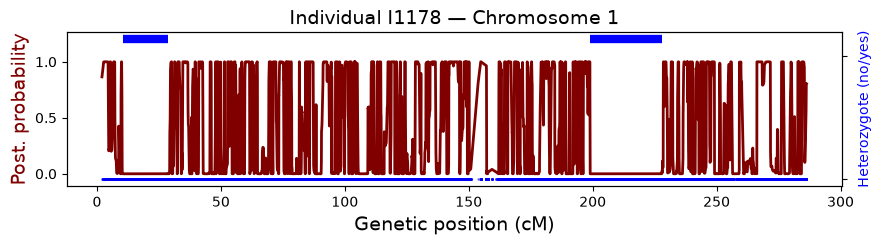

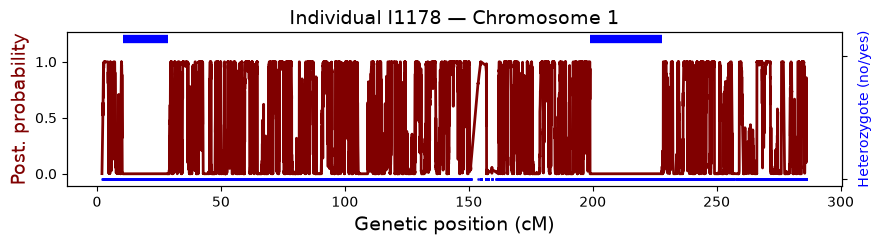

In [17]:
for version in ["_old_version", "_new_version"]:
    fig = plot_posterior(folder=folder_out_base + version, iid=sample_name, chrom=chrom,
                            savepath=None, unit="cM",
                            min_reads=1, min_cm=0,
                            figsize=(10,2))

### Karyotype

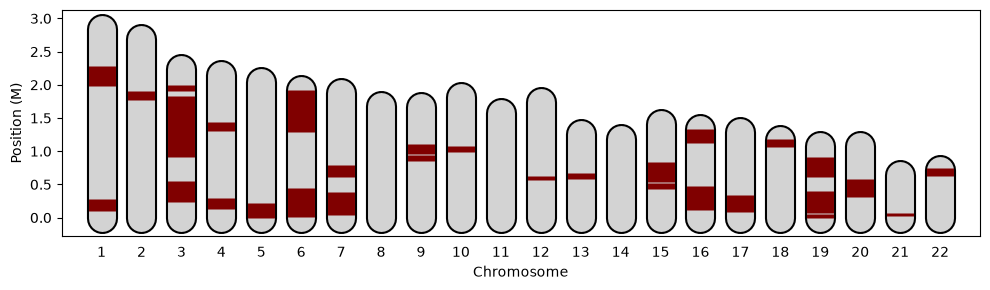

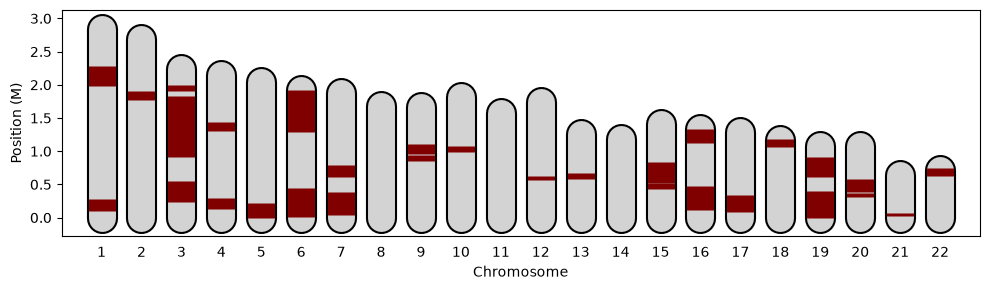

In [18]:
for version in ["_old_version", "_new_version"]:
    fig = plot_roh_karyotype(folder=folder_out_base+version, iid=sample_name,
                            savepath=None, unit="M",
                            figsize=(10,3))

## Old plotting functions
Output differences: 
- creates either a file `readcounts.csv` or `gt_count.csv`. A dummy `hap.csv` is still produced for compatibility
- columns `StartBP` and `EndBP` instead of `Start-` and `EndPosGRCh37` (which are not even always there)

### Posterior probability

In [19]:
from hapsburg.figures.plot_posterior import plot_posterior_cm

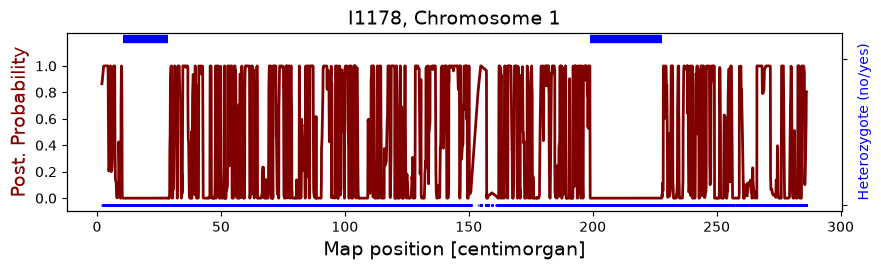

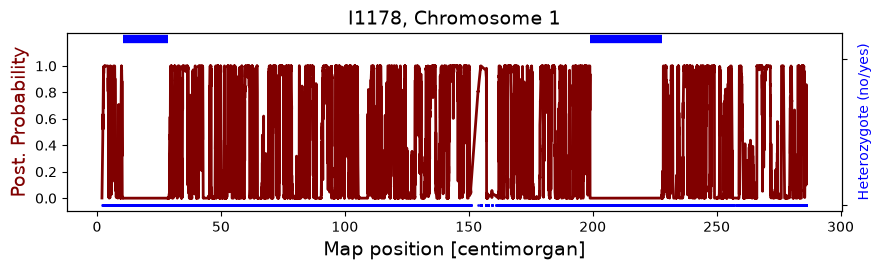

In [20]:
for version in ["_old_version", "_new_version"]:
    plot_posterior_cm(folder=folder_out_base+version+ f"/{sample_name}/chr{chrom}/", savepath="", 
                    empirical=True, m=1, cm_lim=[], groundtruth = False, min_cm=1,
                    readcount=False, figsize=(10,4), title=f"{sample_name}, Chromosome {chrom}")

In [21]:
from hapsburg.figures.plot_individual_roh import plot_roh_individual

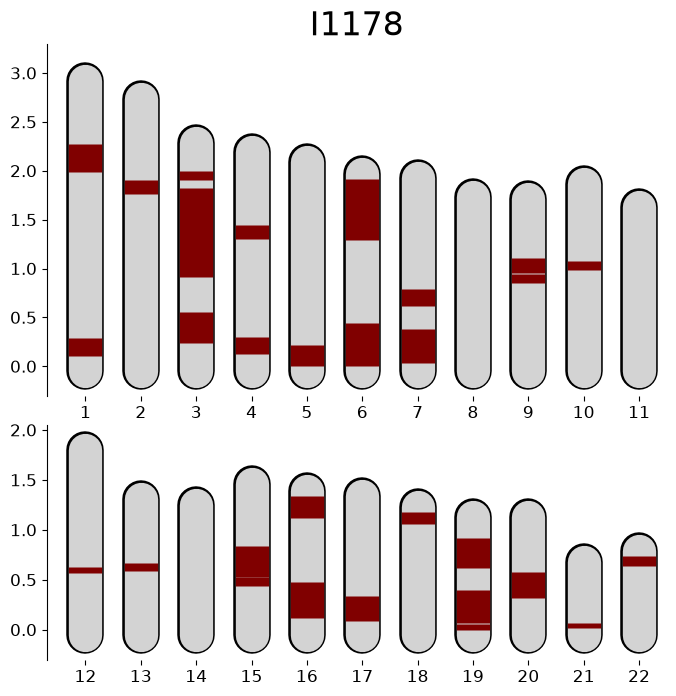

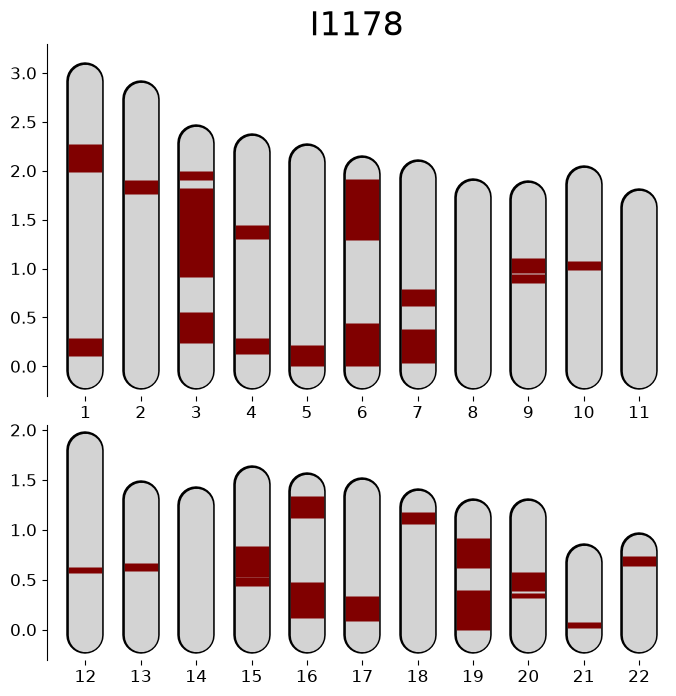

In [22]:
for version in ["_old_version/", "_new_version/"]:
    plot_roh_individual(iid=sample_name, folder=folder_out_base+version, 
                        prefix_out="", min_cm=4, plot_bad=False, savepath="")  

### Do Histogram of the Length Distribution and theoretical expectations

In [23]:
from hapsburg.figures.plot_individual_roh import plot_pde_individual

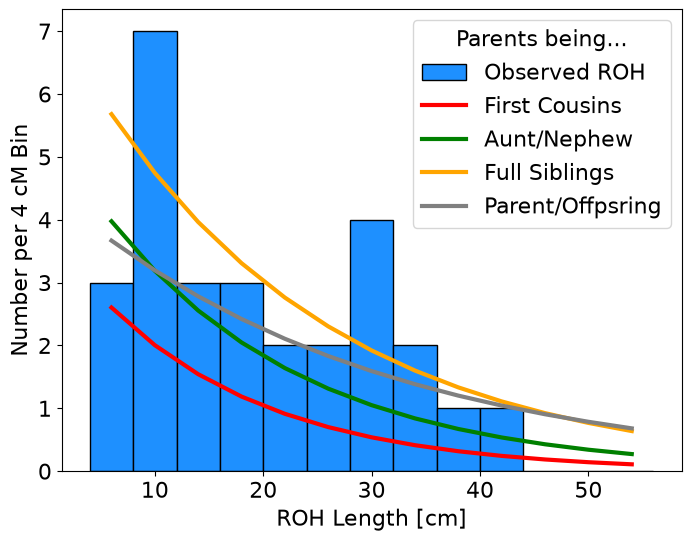

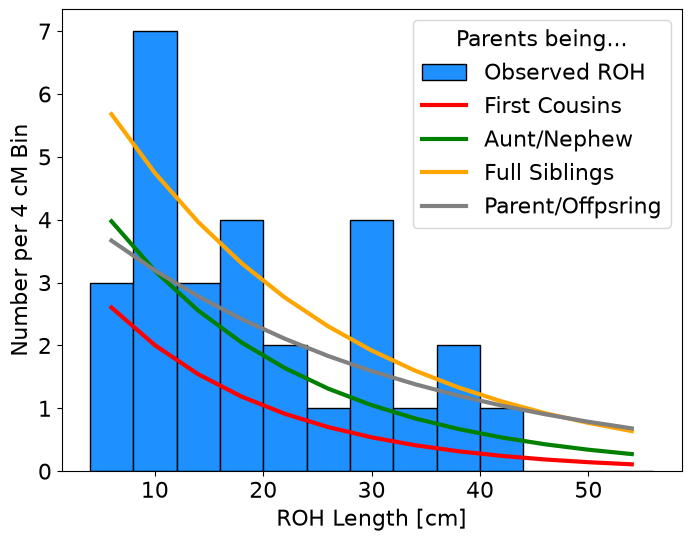

In [24]:
for version in ["_old_version/", "_new_version/"]:
    plot_pde_individual(iid=[sample_name], min_cm=3, bw_cm=4, 
                        kde_plot=False, plotlim=[4, 60], prefix_out="",
                        savepath="", folder=folder_out_base+version)

## 1.1) Plot summary over multiple Individuals

First plot only expectations, for instance as a legend.
You could choose which expectations in the method parameters

In [25]:
from hapsburg.figures.plot_bars import plot_legend_only, plot_panel_row, prepare_dfs_plot

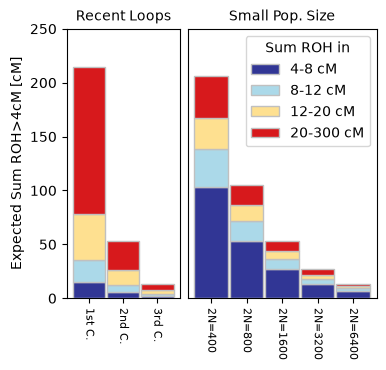

In [26]:
plot_legend_only(savepath="", figsize=(4,3.5))

### Now plot an empirical dataset. 
prepare_dfs_plot prepared from the combined csv (splitting it up into a list of pandas dataframes, these dataframes will be plot in groups - you could also manually produce these lists)

plot_panel_row then plots these data frames  

In this simple usecase, the two individuals analyzed above (from two different populations) are plotted, together with a legend to the right.

In [27]:
df1 = pd.read_csv("./ExampleOutput/combined_roh05.csv", sep='\t')
plot_dfs, cols = prepare_dfs_plot(df1, cms=[4, 8, 12, 20])

# ./figures_test/freilich20_bars.pdf
plot_panel_row(plot_dfs, wspace=0.1, r_title=20, leg_pos=-2, 
               ylim=[0,750], figsize=(8,3.5), savepath="")

FileNotFoundError: [Errno 2] No such file or directory: './ExampleOutput/combined_roh05.csv'